Mounting the [SIIM-ACR dataset](https://www.rsna.org/artificial-intelligence/ai-image-challenge/rsna-pneumonia-detection-challenge-2018)

In [6]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches      # rectangles for bounding boxes
from PIL import Image                      # read JPGs (and their dimensions)

# pydicom for plotting dcm images
import pydicom

# mounting data
import zipfile
from zipfile import ZipFile
from pathlib import Path
import random

In [7]:
# Kind of stupid but don't need to create a new folder, just run normally, grabs from zipped folder

# Attach path
DATA_DIR = Path("/Users/emilyahmad/DataScience/AIMI/datasets/SIM-ACR-Data.zip")
assert DATA_DIR.exists(), f"dataset not found at {DATA_DIR}."
# Unzip
with ZipFile(DATA_DIR, "r") as zObject:
    zObject.extractall(path="/Users/emilyahmad/DataScience/AIMI/datasets/SIM-ACR-Data")
# Change path to SIM-ACR folder instead of zip
DATA_DIR = DATA_DIR.with_suffix("")

Need to understand how the dataset is divided before moving to training/test sets
Each folder as a series of numbers, ex. 1.2.276.0.7230010.3.1.2.8323329.1498.1517874291.247600
I'll check out the [dataset description](https://www.rsna.org/-/media/Files/RSNA/Education/AI%20resources%20and%20training/AI%20image%20challenge/RSNA-2018-Pneumonia-Detection-Challenge-Dataset-Description.ashx?la=en&hash=8331DDFA52AA5EE9C3C99B5983BB680D7BD2ABBF&hash=8331DDFA52AA5EE9C3C99B5983BB680D7BD2ABBF%27) to determine how I'll sort them

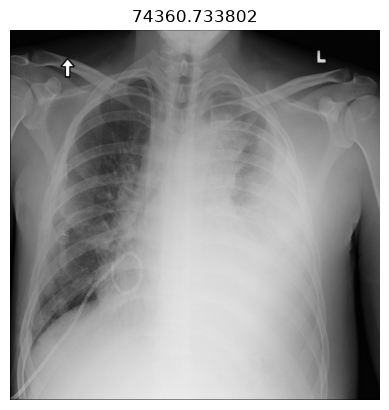

In [8]:
# Plot a random DICOM

# simply passing the path into dcmread() fails, not recognized as a DICOM file
# old method adds __MACOSX (metadata folder when zipping) and .__ (AppleDouble resource-fork stub_ prevent by using rglob
files = [p for p in DATA_DIR.rglob("*.dcm")
         if "__MACOSX" not in p.parts and not p.name.startswith("._")]

path = random.choice(files)
ds = pydicom.dcmread(path)
img = ds.pixel_array
if ds.PhotometricInterpretation == "MONOCHROME1":
    img = img.max() - img

plt.imshow(img, cmap="gray")
plt.title(path.stem[-12:])
plt.axis("off")
plt.show()